In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initialise vars

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

In [5]:
news_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news_comments.csv'
nonnews_merged_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews_comments.csv'

In [6]:
news_df = pd.read_csv(news_merged_filepath)
nonnews_df = pd.read_csv(nonnews_merged_filepath) 

In [7]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [8]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [9]:
news_df.shape, nonnews_df.shape

((1279, 14), (1367, 14))

In [10]:
news_df.drop(columns=['caption'], inplace=True)
nonnews_df.drop(columns=['caption'], inplace=True)

In [11]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(330)

In [12]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [13]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [14]:
news_df.shape, nonnews_df.shape

((980, 13), (1037, 13))

### plotting

division by zero msnbc DRX71AeCgTh 0 10
division by zero msnbc DRYGzcyEsGL 0 10


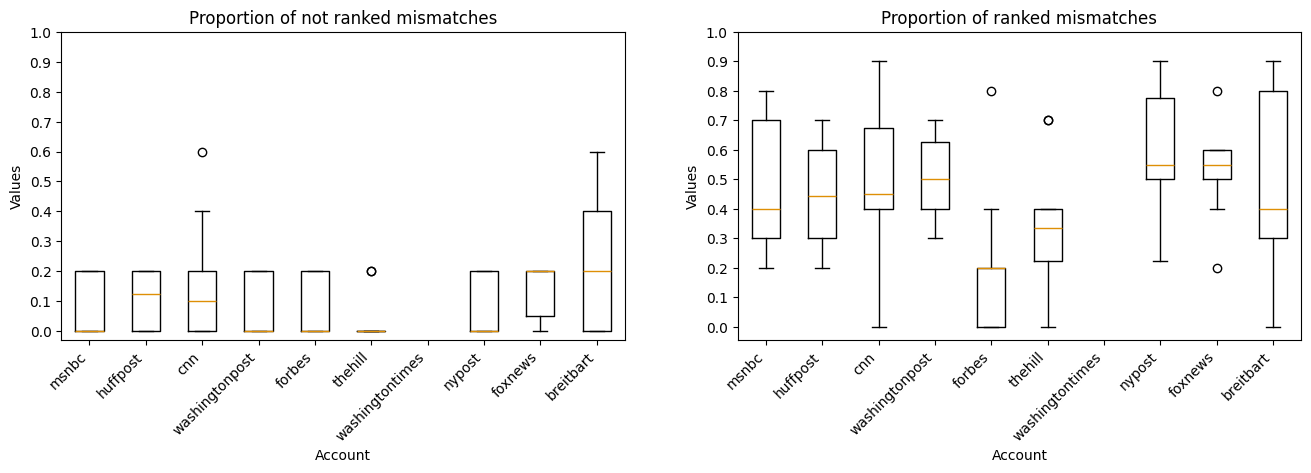

In [18]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

crawl1 = 'male_dem_ny_1'
crawl2 = 'female_rep_ny_1'

temp_df = plot_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, plot_urls)


accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

In [15]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

news_mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
news_mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

news_mismatch_no_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

news_mismatch_no_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

news_mismatch_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

news_mismatch_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)


# fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# hm0 = sns.heatmap(
#     news_mismatch_no_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[0], cbar=False
# )
# axes[0].set_title(f"Average mismatch proportion for {flag} accounts across all pairs of crawls")

# hm1 = sns.heatmap(
#     news_mismatch_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[1], cbar=False
# )
# axes[1].set_title(f"Rank mismatch: {flag}")

# cbar = fig.colorbar(
#     hm0.collections[0],
#     ax=axes,
#     orientation="vertical",
#     location="left", 
#     pad=0.02,
#     fraction=0.06,
#     aspect=40
# )
# cbar.ax.xaxis.set_ticks_position("top")
# cbar.ax.xaxis.set_label_position("top")

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRX7mPtkhbo 0 0
division by zero msnbc DRXeikNDutF 0 0
division by zero msnbc DRXyanzDw2z 0 0
division by zero msnbc DRYGzcyEsGL 0 0


In [16]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

nonnews_mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
nonnews_mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

nonnews_mismatch_no_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

nonnews_mismatch_no_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

nonnews_mismatch_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

nonnews_mismatch_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)


# fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# hm0 = sns.heatmap(
#     nonnews_mismatch_no_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[0], cbar=False
# )
# axes[0].set_title(f"Average mismatch proportion for {flag} accounts across all pairs of crawls")

# hm1 = sns.heatmap(
#     nonnews_mismatch_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[1], cbar=False
# )
# axes[1].set_title(f"Rank mismatch: {flag}")

# cbar = fig.colorbar(
#     hm0.collections[0],
#     ax=axes,
#     orientation="vertical",
#     location="left", 
#     pad=0.02,
#     fraction=0.06,
#     aspect=40
# )
# cbar.ax.xaxis.set_ticks_position("top")
# cbar.ax.xaxis.set_label_position("top")

division by zero catloversclub DSC60BKkrYV 0 0
division by zero ladbible DSAzKDHjI_T 0 0
division by zero ladbible DSCoNYQDAK- 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero accesshollywood DSDU9GlDmn4 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catl

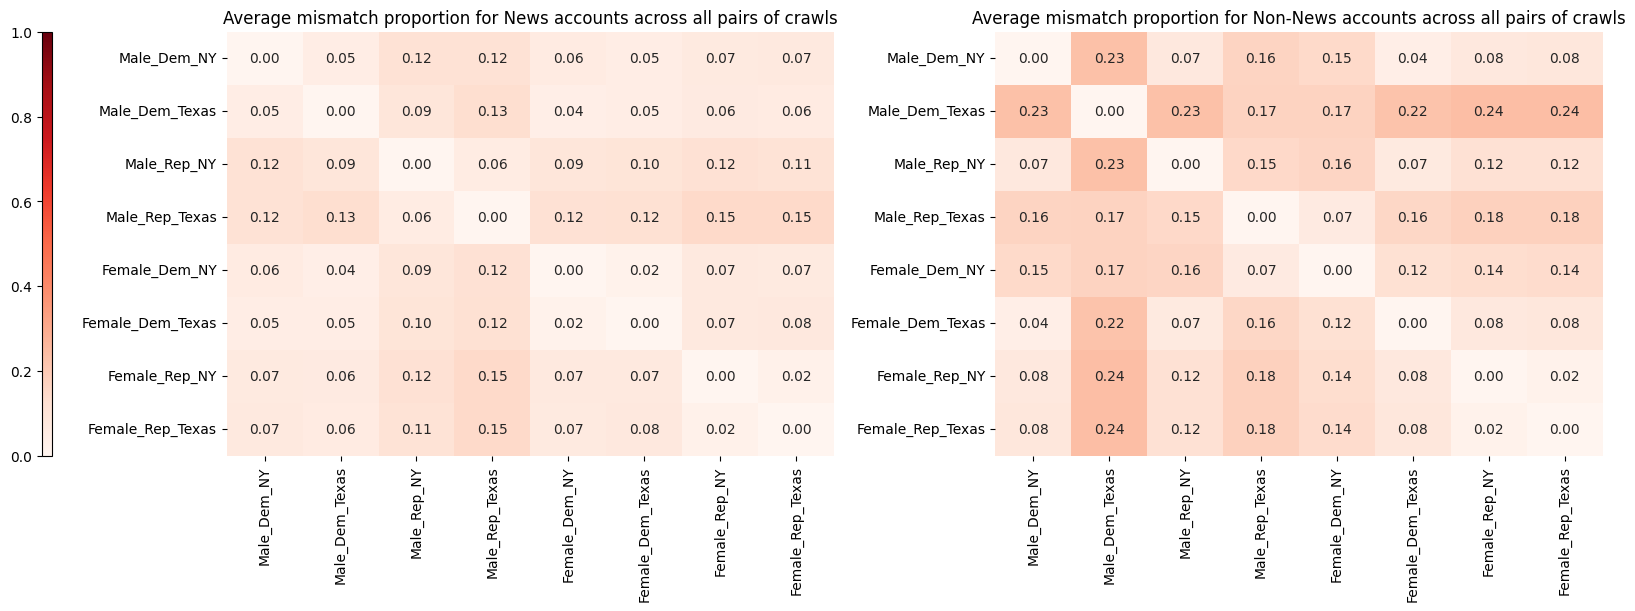

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

hm0 = sns.heatmap(
    news_mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[0], cbar=False
)
axes[0].set_title(f"Average mismatch proportion for News accounts across all pairs of crawls")

hm1 = sns.heatmap(
    nonnews_mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[1], cbar=False
)
axes[1].set_title(f"Average mismatch proportion for Non-News accounts across all pairs of crawls")

cbar = fig.colorbar(
    hm0.collections[0],
    ax=axes,
    orientation="vertical",
    location="left", 
    pad=0.02,
    fraction=0.06,
    aspect=40
)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

plt.savefig('/Users/brahmaninutakki/saarland/insta-comments/figures/heatmaps_no_rank.png', dpi=300)

### post level reg 

In [16]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)
reg_nonnews_df = get_df_for_regression(nonnews_df, nonnews_urls, all_crawls) 

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 

In [17]:
reg_news_df.shape, reg_nonnews_df.shape

((4648, 9), (4312, 9))

In [18]:
reg_news_df.drop_duplicates(inplace=True)
reg_nonnews_df.drop_duplicates(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2121, 9), (2089, 9))

In [19]:
reg_news_df.dropna(inplace=True)
reg_nonnews_df.dropna(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2121, 9), (2089, 9))

In [20]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

reg_nonnews_df = pd.merge(reg_nonnews_df, accounts_data, on='account', how='inner')
reg_nonnews_df.shape

(2089, 12)

In [21]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='account', how='inner')
reg_news_df.shape

(2121, 15)

In [22]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_nonnews.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_nonnews_df = reg_nonnews_df.merge(comments_df, on='urlid', how='left')
reg_nonnews_df = reg_nonnews_df.merge(likes_df, on='urlid', how='left')

reg_nonnews_df[reg_nonnews_df['comments_count'].isna()]['urlid'].unique()

array(['DSC60BKkrYV'], dtype=object)

In [23]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_news_df = reg_news_df.merge(comments_df, on='urlid', how='left')
reg_news_df = reg_news_df.merge(likes_df, on='urlid', how='left')

reg_news_df[reg_news_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [24]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='urlid', how='outer')

reg_news_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,1394.000000,727.000000
mean,853.671449,1827.634113
std,2134.126414,3092.699244
min,14.000000,17.000000
25%,89.000000,116.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [25]:
reg_news_df['comments_count'] = reg_news_df["comments_count"].fillna(reg_news_df["comments_mising"])
reg_news_df[['comments_count', 'comments_mising']].describe()
reg_news_df.drop(columns=['comments_mising'], inplace=True)

In [26]:
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['urlid'] != 'DSC60BKkrYV']

In [27]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_news_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_news_df['urlid'].nunique()

reg_news_df = pd.merge(reg_news_df, posts_data, on='urlid', how='inner')
reg_news_df.drop(columns=['Url'], inplace=True)
reg_news_df.shape

(2121, 21)

In [28]:
reg_news_df['type'] = 'News'
reg_nonnews_df['main_topic'] = 'Non-Political'
reg_nonnews_df['type'] = 'Non-News'

In [29]:
concat_df = pd.concat([reg_nonnews_df, reg_news_df], ignore_index=True)
concat_df.shape

(4189, 22)

In [30]:
def preprocess_reg(df):
    df['fcount_no_rank'] = df['fcount_no_rank'].astype(int)
    df['ftrials_no_rank'] = df['ftrials_no_rank'].astype(int)
    df['fcount_rank'] = df['fcount_rank'].astype(int)
    df['ftrials_rank'] = df['ftrials_rank'].astype(int)

    (df[df['fcount_no_rank'] > df['ftrials_no_rank']]).shape, (df[df['fcount_rank'] > df['ftrials_rank']]).shape

    df['gender_diff'] = df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
    df['location_diff'] = df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
    df['ideology_diff'] = df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

    for col in ["posts", "followers", "following", "comments_count"]:
        new = col + "_logz"
        x = np.log1p(df[col].astype(float))
        df[new] = (x - x.mean()) / x.std(ddof=0)


    df["gender"] = pd.Categorical(
        df["gender"],
        categories=["male_male", "female_male", "female_female"],
        ordered=True
    )

    df["ideology"] = pd.Categorical(
        df["ideology"],
        categories=["rep_rep", "dem_rep", "dem_dem"],
        ordered=True
    )

    df["location"] = pd.Categorical(
        df["location"],
        categories=["texas_texas", "ny_texas", "ny_ny"],
        ordered=True
    )

    df['type'] = pd.Categorical(
        df['type'],
        categories=['Non-News', 'News'],
        ordered=True
    )


    df['main_topic'] = pd.Categorical(
        df['main_topic'],
        categories=['Political', 'Non-Political'],
        ordered=True
    )

    df["gender_diff"] = pd.Categorical(
        df["gender_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    df["ideology_diff"] = pd.Categorical(
        df["ideology_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    df["location_diff"] = pd.Categorical(
        df["location_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    return df

In [31]:
concat_df = preprocess_reg(concat_df)
reg_news_df = preprocess_reg(reg_news_df)
reg_nonnews_df = preprocess_reg(reg_nonnews_df)

In [32]:
news_df['account'].value_counts()

account
cnn               130
foxnews           119
nypost            112
huffpost          110
breitbart         108
msnbc             105
thehill           105
forbes             99
washingtonpost     92
Name: count, dtype: int64

In [33]:
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(type) + C(main_topic) + followers_logz + comments_count_logz + followers_logz + following_logz + posts_logz " 
get_vif(formula, concat_df)

,feature,VIF
8,following_logz,1.042193
1,gender_diff[T.Yes],1.082412
3,ideology_diff[T.Yes],1.084033
2,location_diff[T.Yes],1.092294
9,posts_logz,1.185065
6,followers_logz,1.274489
7,comments_count_logz,1.370502
4,C(type)[T.News],1.523143
5,C(main_topic)[T.Non-Political],1.805873
0,Intercept,16.711977


In [34]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + political_ideology + main_topic + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
)
var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'comments_count_logz', 'main_topic', 'political_ideology', 'followers_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, followers_logz, comments_count_logz, political_ideology, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

ValueError: Not enough samples to build a trace.

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.769,3.258,-9.441,2.925,0.093,0.075,1213.0,903.0,1.00
location_diff[Yes],-0.256,0.062,-0.367,-0.134,0.001,0.002,2885.0,987.0,1.00
gender_diff[Yes],0.243,0.059,0.135,0.354,0.001,0.002,2611.0,979.0,1.00
ideology_diff[Yes],0.322,0.063,0.207,0.441,0.001,0.002,3195.0,1289.0,1.00
comments_count_logz,0.749,0.222,0.356,1.172,0.009,0.006,649.0,902.0,1.00
main_topic[Non-Political],-0.107,0.454,-0.982,0.696,0.019,0.013,572.0,747.0,1.00
political_ideology[Center-Left],-0.098,4.731,-8.662,8.097,0.114,0.131,1745.0,1074.0,1.00
political_ideology[Center-Right],-0.200,5.634,-10.206,9.666,0.135,0.148,1723.0,1202.0,1.00
political_ideology[Left],-0.035,4.618,-8.211,8.851,0.101,0.125,2074.0,1136.0,1.00
political_ideology[Right],0.429,3.276,-5.432,6.921,0.096,0.073,1173.0,989.0,1.00


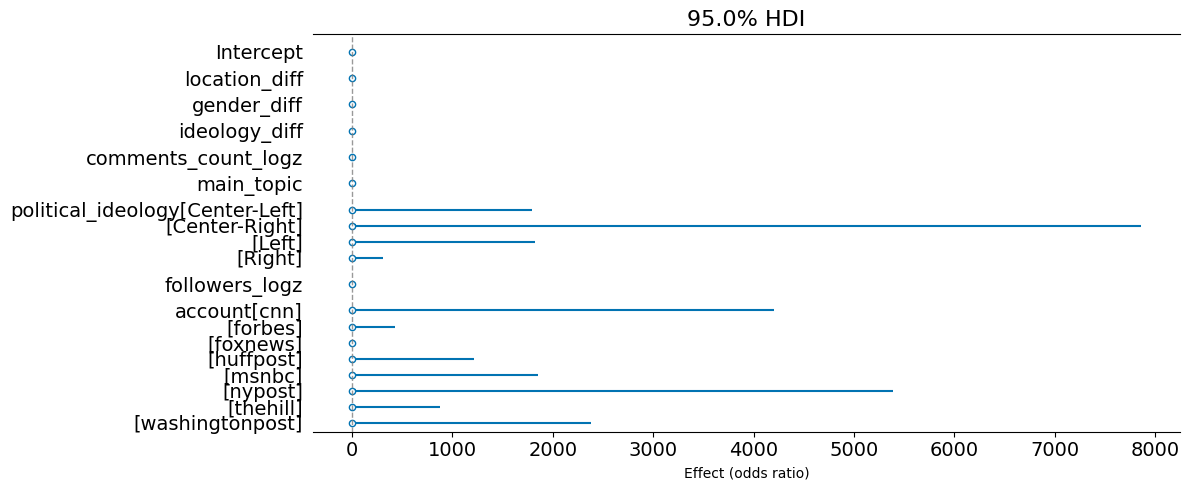

In [38]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + political_ideology + main_topic + account + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=800,      
    tune=800,       
    target_accept=0.97,
    chains=2,
    cores=1,
    random_seed=42,
)
var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'comments_count_logz', 'main_topic', 'political_ideology', 'followers_logz', 'account']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, followers_logz, comments_count_logz, type, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 654 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.637,0.283,-2.162,-1.115,0.009,0.006,965.0,1738.0,1.00
location_diff[Yes],-0.202,0.039,-0.273,-0.128,0.000,0.000,11821.0,5890.0,1.00
gender_diff[Yes],0.154,0.038,0.085,0.229,0.000,0.000,9850.0,6104.0,1.00
ideology_diff[Yes],0.103,0.039,0.029,0.174,0.000,0.000,11482.0,5729.0,1.00
comments_count_logz,0.557,0.099,0.370,0.733,0.003,0.001,1260.0,2456.0,1.00
main_topic[Non-Political],-0.323,0.258,-0.818,0.140,0.008,0.005,973.0,1876.0,1.00
type[News],-1.178,0.213,-1.558,-0.763,0.007,0.004,1042.0,1806.0,1.00
followers_logz,-0.196,0.096,-0.366,-0.011,0.003,0.001,965.0,1888.0,1.01


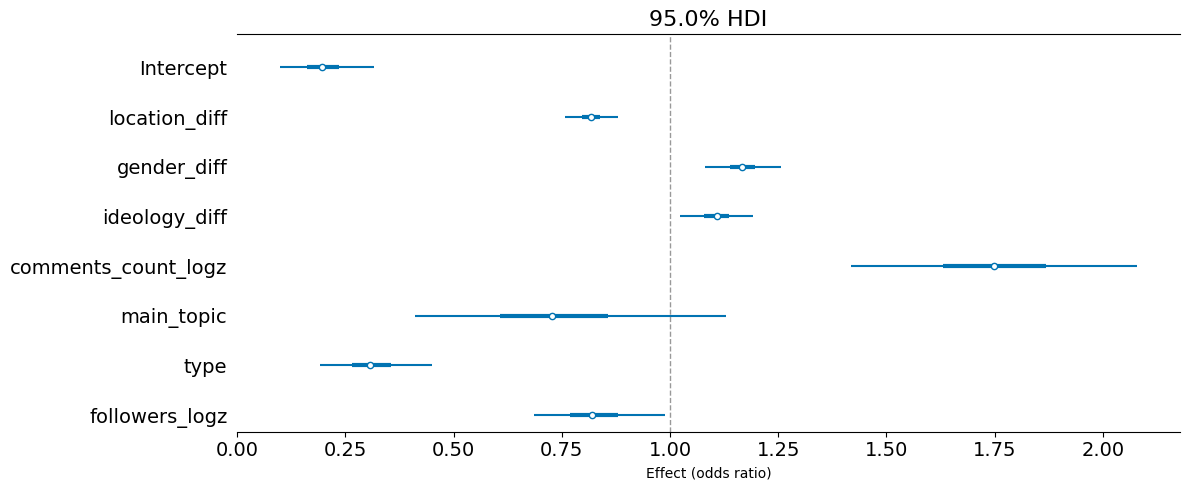

In [39]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + type + main_topic + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)
var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'comments_count_logz', 'main_topic', 'type', 'followers_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, comments_count_logz, type, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 550 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.506,0.263,-1.961,-0.972,0.009,0.005,877.0,1583.0,1.00
location_diff[Yes],-0.203,0.038,-0.275,-0.134,0.000,0.000,8083.0,5888.0,1.00
gender_diff[Yes],0.154,0.038,0.081,0.223,0.000,0.000,7248.0,5546.0,1.00
ideology_diff[Yes],0.102,0.039,0.028,0.176,0.000,0.000,7023.0,5590.0,1.00
comments_count_logz,0.477,0.092,0.297,0.644,0.003,0.002,773.0,1283.0,1.00
main_topic[Non-Political],-0.490,0.237,-0.967,-0.068,0.007,0.005,1015.0,1620.0,1.01
type[News],-1.183,0.204,-1.575,-0.803,0.007,0.004,773.0,1481.0,1.01


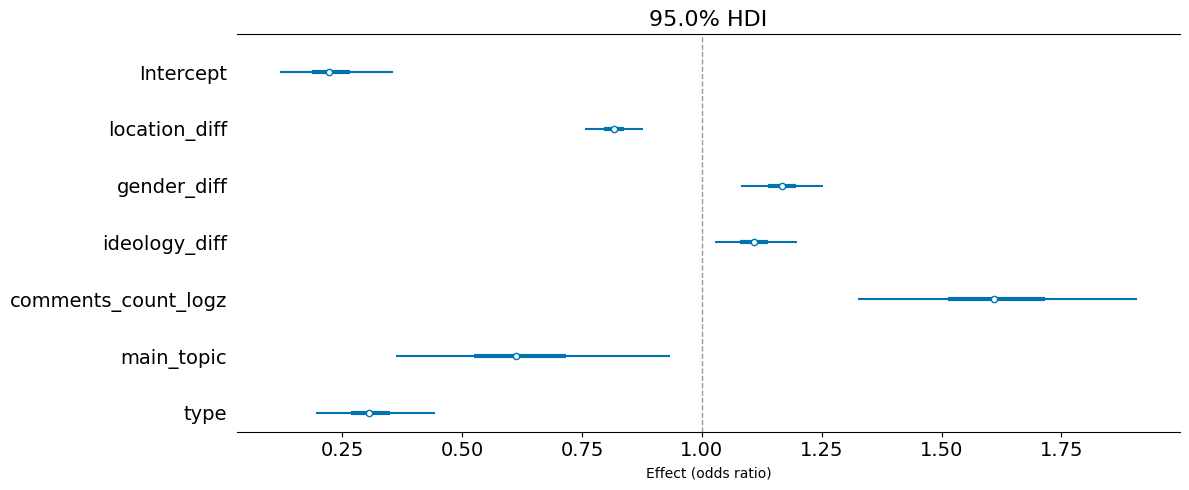

In [40]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + comments_count_logz + type + main_topic + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)
var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'comments_count_logz', 'main_topic', 'type']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, followers_logz, comments_count_logz, type, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 709 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.999,0.289,-1.540,-0.461,0.009,0.005,1143.0,2199.0,1.00
location[ny_texas],-0.376,0.045,-0.462,-0.293,0.000,0.000,10821.0,6127.0,1.00
location[ny_ny],-0.365,0.053,-0.468,-0.267,0.001,0.001,11197.0,6367.0,1.00
gender[female_male],-0.174,0.045,-0.255,-0.087,0.000,0.001,10041.0,5941.0,1.00
gender[female_female],-0.720,0.059,-0.829,-0.607,0.001,0.001,10230.0,5939.0,1.00
ideology[dem_rep],-0.007,0.046,-0.092,0.081,0.000,0.000,10621.0,6567.0,1.00
ideology[dem_dem],-0.207,0.057,-0.311,-0.096,0.001,0.001,10435.0,6647.0,1.00
comments_count_logz,0.556,0.102,0.359,0.740,0.003,0.002,1013.0,2046.0,1.00
main_topic[Non-Political],-0.360,0.262,-0.845,0.141,0.008,0.005,1128.0,1839.0,1.01
type[News],-1.218,0.217,-1.632,-0.817,0.006,0.003,1220.0,2160.0,1.00


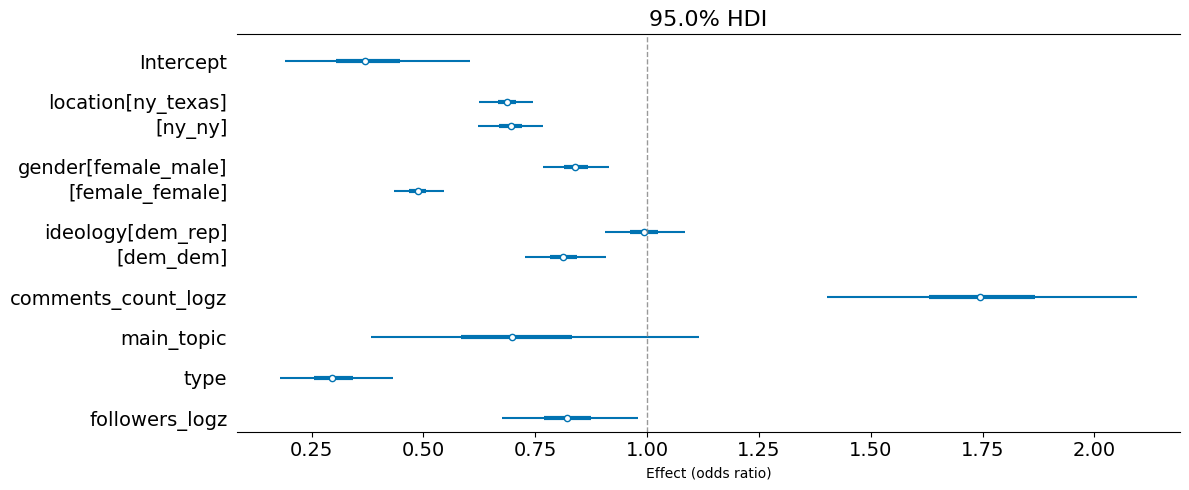

In [41]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + followers_logz + comments_count_logz + type + main_topic + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)
var_names = ['Intercept', 'location', 'gender', 'ideology', 'comments_count_logz', 'main_topic', 'type', 'followers_logz']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

In [35]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + followers_logz + comments_count_logz + type + account + main_topic + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
)
var_names = ['Intercept', 'location', 'gender', 'ideology', 'comments_count_logz', 'main_topic', 'type', 'followers_logz', 'account']
display(az.summary(results, var_names=var_names))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names=var_names
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, followers_logz, comments_count_logz, type, account, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()